# License Plate Recognition Notebook;
- inspecting preprocessing output
- inspecting contour detection output
- inspecting the cropped OCR region
- tuning thresholds in `AppConfig`
- running OCR and compare results

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/Users/najib/OneDrive/Documents/New project')

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

from src.config import AppConfig
from src.ocr import extract_text_from_plate
from src.plate_detector import detect_plate
from src.postprocess import clean_plate_text, is_plausible_plate
from src.preprocess import preprocess_for_plate_detection, preprocess_plate_for_ocr

In [3]:
def show_image(image, title: str, *, gray: bool = False, figsize=(10, 5)) -> None:
    plt.figure(figsize=figsize)
    if image.ndim == 2 or gray:
        plt.imshow(image, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()


def show_grid(items, cols: int = 2, figsize=(14, 8)) -> None:
    rows = int(np.ceil(len(items) / cols))
    plt.figure(figsize=figsize)
    for index, (title, image, gray) in enumerate(items, start=1):
        plt.subplot(rows, cols, index)
        if image.ndim == 2 or gray:
            plt.imshow(image, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## 1. Configure Input and Tunable Parameters

In [4]:
IMAGE_PATH = PROJECT_ROOT / 'data' / 'input' / 'CAR 3.jpg' 

#IMAGE_PATH = PROJECT_ROOT / 'data' / 'input' / 'monaco_plate.jpg'
TESSERACT_CMD = r'C:\PROGRA~1\Tesseract-OCR\tesseract.exe'

config = AppConfig()
config.tesseract_cmd = TESSERACT_CMD

# Tune these values during experiments.
config.canny_threshold_1 = 30  # Lower for more edges
config.canny_threshold_2 = 120  # Lower for more edges
config.min_plate_area_ratio = 0.005  # Smaller plates
config.max_plate_area_ratio = 0.90   # Larger plates
config.min_plate_aspect_ratio = 1.5   # More varied shapes
config.max_plate_aspect_ratio = 8.0   # More varied shapes
config.ideal_plate_aspect_ratio = 3.5  # Adjust for German plates
config.min_rectangularity = 0.25       # Less strict
config.min_edge_density = 0.005        # Less strict
config.ocr_lower_region_start = 0.35

IMAGE_PATH

WindowsPath('C:/Users/najib/OneDrive/Documents/New project/data/input/CAR 3.jpg')

## 2. Load the Input Image

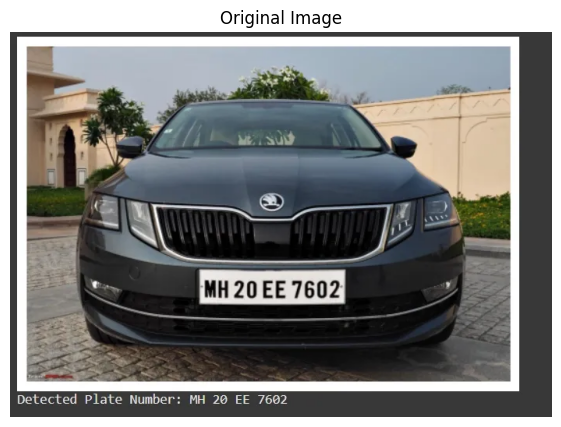

In [5]:
image = cv2.imread(str(IMAGE_PATH))
if image is None:
    raise FileNotFoundError(IMAGE_PATH)

show_image(image, 'Original Image')

## 3. Inspect Preprocessing Output

This cell shows the resized image, enhanced grayscale image, and the edge map used for contour search.

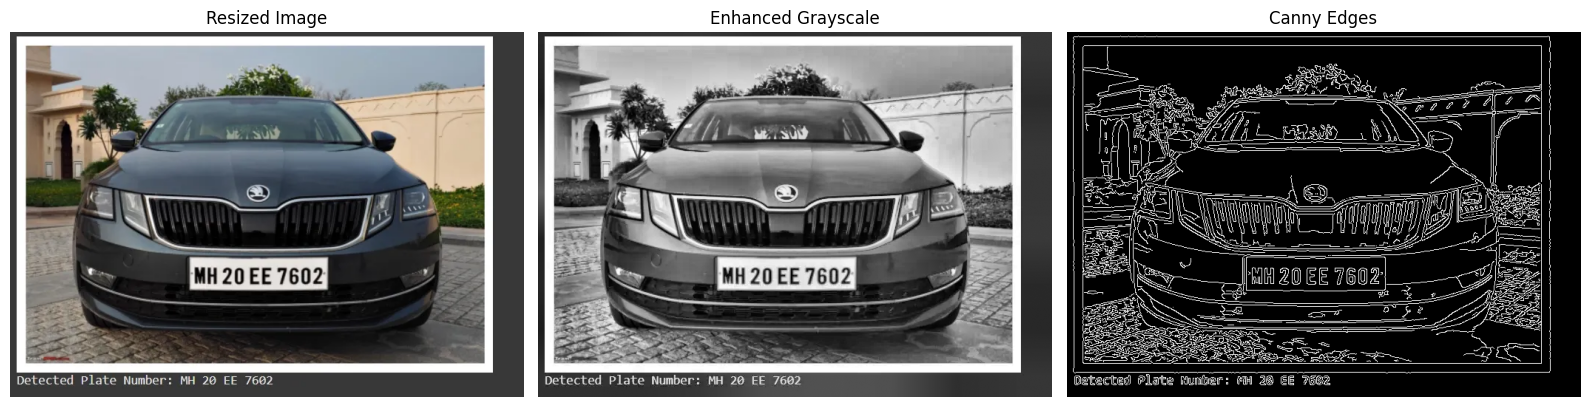

In [6]:
resized, enhanced_gray, edged = preprocess_for_plate_detection(image, config)

show_grid([
    ('Resized Image', resized, False),
    ('Enhanced Grayscale', enhanced_gray, True),
    ('Canny Edges', edged, True),
], cols=3, figsize=(16, 5))

## 4. Inspect Raw Contours

This helps answer whether the plate border is even visible in the current edge map.

Total contours found: 1018


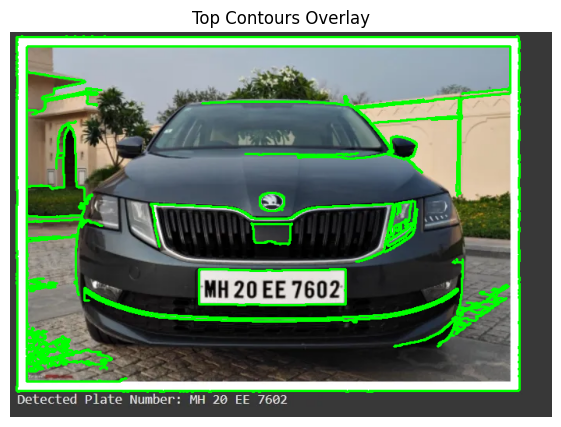

In [7]:
contours, _ = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
top_contours = sorted(contours, key=cv2.contourArea, reverse=True)[:15]

contour_overlay = resized.copy()
cv2.drawContours(contour_overlay, top_contours, -1, (0, 255, 0), 2)

print(f'Total contours found: {len(contours)}')
show_image(contour_overlay, 'Top Contours Overlay')

## 5. Run Plate Detection

Detection score: 0.731
Bounding box: (242, 304, 189, 46)


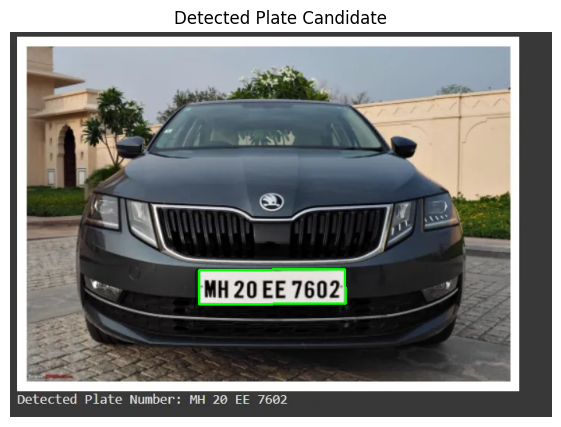

In [8]:
detection = detect_plate(image, config)
if detection is None:
    print("No plate detected. Debugging info:")
    print(f"Total contours found: {len(contours)}")
    print("Check the contour overlay above to see if plate edges are detected.")
    print("Try adjusting the parameters above and re-running cells 3-5.")
    raise RuntimeError('No plate candidate detected. Tune preprocessing or contour settings.')

print(f'Detection score: {detection.score:.3f}')
print(f'Bounding box: {detection.bounding_box}')

show_image(detection.debug_image, 'Detected Plate Candidate')

## 6. Inspect the Plate Crop and OCR Input

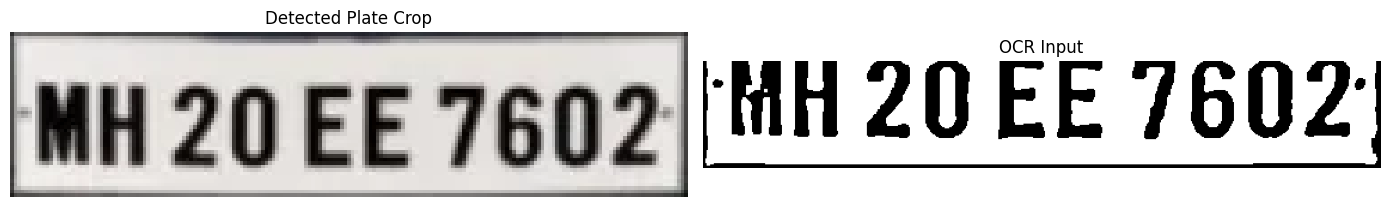

In [9]:
plate_crop = detection.text_roi
ocr_input = preprocess_plate_for_ocr(plate_crop, config)

show_grid([
    ('Detected Plate Crop', plate_crop, False),
    ('OCR Input', ocr_input, True),
], cols=2, figsize=(14, 5))

## 7. Run OCR

In [10]:
raw_text = extract_text_from_plate(ocr_input, config)
cleaned_text = clean_plate_text(raw_text)
plausible = is_plausible_plate(cleaned_text)

print(f'Raw OCR text: {raw_text!r}')
print(f'Cleaned OCR text: {cleaned_text or "N/A"}')
print(f'Plausible plate: {plausible}')

Raw OCR text: 'MHZOEE602\n'
Cleaned OCR text: MHZOEE602
Plausible plate: False


## 8. Suggested Tuning Order

When OCR is wrong, tune in this order:
1. `canny_threshold_1` and `canny_threshold_2`
2. `min_plate_area_ratio` and `ideal_plate_aspect_ratio`
3. `ocr_lower_region_start`
4. `adaptive_block_size`, `adaptive_c`, and `ocr_scale_factor`

After changing values, rerun cells 3 through 7.